
This notebook explores the Lotka-Volterra data, in preparation of preprocessing.

1. Visualising Example Trajectories
2. Analysing for Scaling & Rounding
    - 2.1 Visualising Distribution
    - 2.2 Visualising Scaled and Rounded Trajectories
    - 2.3 My Choice


In [1]:
import h5py as h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

plt.style.use('mystyle.mplstyle')
data_path = "../lotka_volterra_data.h5"
!mkdir -p ../results/figures

In [2]:
with h5py.File(data_path, "r") as f:
    # Print the keys in the file
    print("Keys in the HDF5 file:", list(f.keys()))
    
    # Access the full dataset
    trajectories = f["trajectories"][:]
    time_points = f["time"][:]
    
    # Print dataset shapes
    print(f"Trajectories shape: {trajectories.shape}")
    print(f"Time points shape: {time_points.shape}")

# Examine the first few time points
print("First 5 time points:", time_points[:5])

Keys in the HDF5 file: ['time', 'trajectories']
Trajectories shape: (1000, 100, 2)
Time points shape: (100,)
First 5 time points: [0.         2.02020202 4.04040404 6.06060606 8.08080808]


## 1. Visualising Example Trajectories

The classic Lotka-Volterra dynamics typically show oscillatory behavior where:
1. Prey population increases
2. Predator population increases in response (with a delay)
3. Increased predation causes prey population to decrease
4. Predator population decreases due to lack of food
5. Cycle repeats

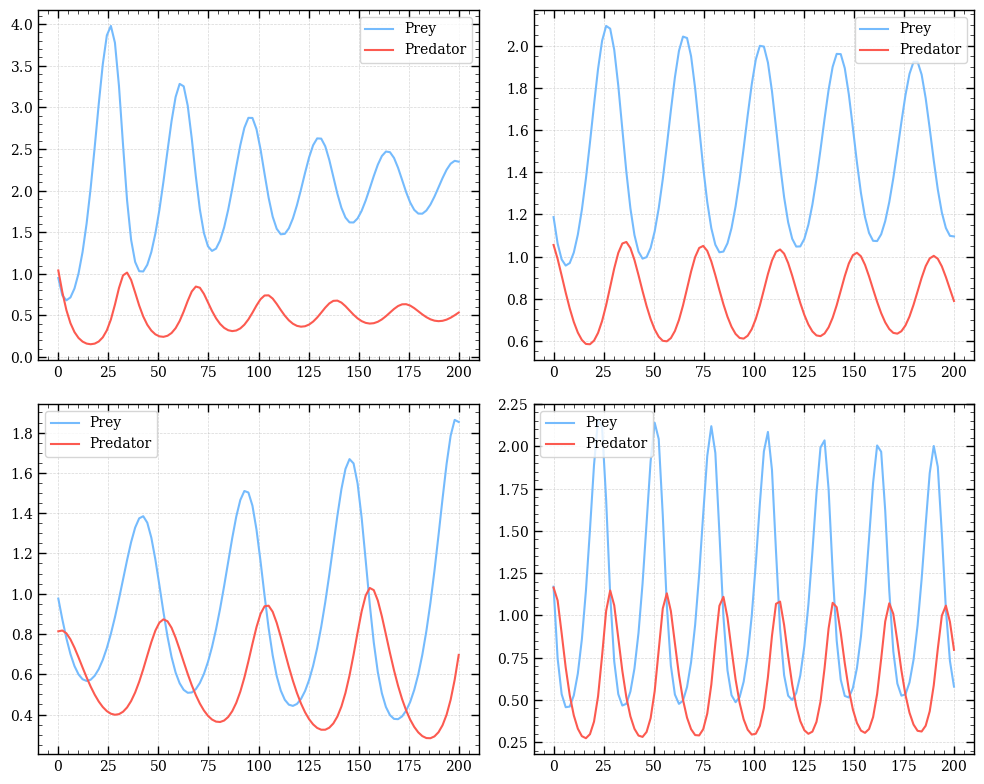

In [3]:
# Plot a few more trajectories to see the variety
plt.figure(figsize=(10, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    system_id = i * 100  # Sample different systems
    plt.plot(time_points, trajectories[system_id, :, 0], label='Prey')
    plt.plot(time_points, trajectories[system_id, :, 1], label='Predator')
    # plt.xlabel('Time')
    # plt.ylabel('Population')
    # plt.title(f'System {system_id}')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Analysing for Scaling & Rounding

## 2.1 Visualising Distribution

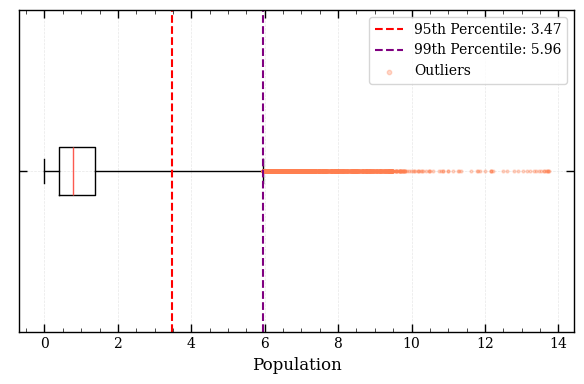

In [15]:
traj_values = trajectories.flatten()
traj_percentiles = {
    'min': np.min(traj_values),
    '5th': np.percentile(traj_values, 5),
    '25th': np.percentile(traj_values, 25),
    '50th': np.percentile(traj_values, 50),  # median
    '75th': np.percentile(traj_values, 75),
    '95th': np.percentile(traj_values, 95),
    '99th': np.percentile(traj_values, 99),
}

# Create a visualization of the percentiles with outliers
plt.figure(figsize=(6, 4))

# Custom outlier properties
flierprops = dict(marker='o', markersize=2, markerfacecolor='coral', markeredgecolor='coral', alpha=0.3)  # Smaller and transparent outliers

plt.boxplot(traj_values, vert=False, showfliers=True,  # Show outliers
            whis=[0, 99], tick_labels=[' '],
            flierprops=flierprops)
plt.axvline(traj_percentiles['95th'], color='r', linestyle='--', 
            label=f'95th Percentile: {traj_percentiles["95th"]:.2f}')
plt.axvline(traj_percentiles['99th'], color='purple', linestyle='--', 
            label=f'99th Percentile: {traj_percentiles["99th"]:.2f}')
outlier_legend = plt.scatter([], [], color='coral', alpha=0.3, s=10, label="Outliers")
plt.xlabel('Population')
plt.legend()
plt.grid(True, alpha=0.3)

# Add text annotations for key percentiles
# for label, value in traj_percentiles.items():
#     if label in ['95th', '99th']:
#         plt.text(value, 1.1, f'{label}: {value:.2f}', 
#                  horizontalalignment='center', size='small')

plt.tight_layout()
plt.savefig('../results/figures/boxplot.pdf')
plt.show()

### 2.2 Visualising Scaled and Rounded Trajectories

Scaling to a smaller range or rounding the decimal places can cause a loss of information.

Avoid making the data too rough due to the loss of information. 

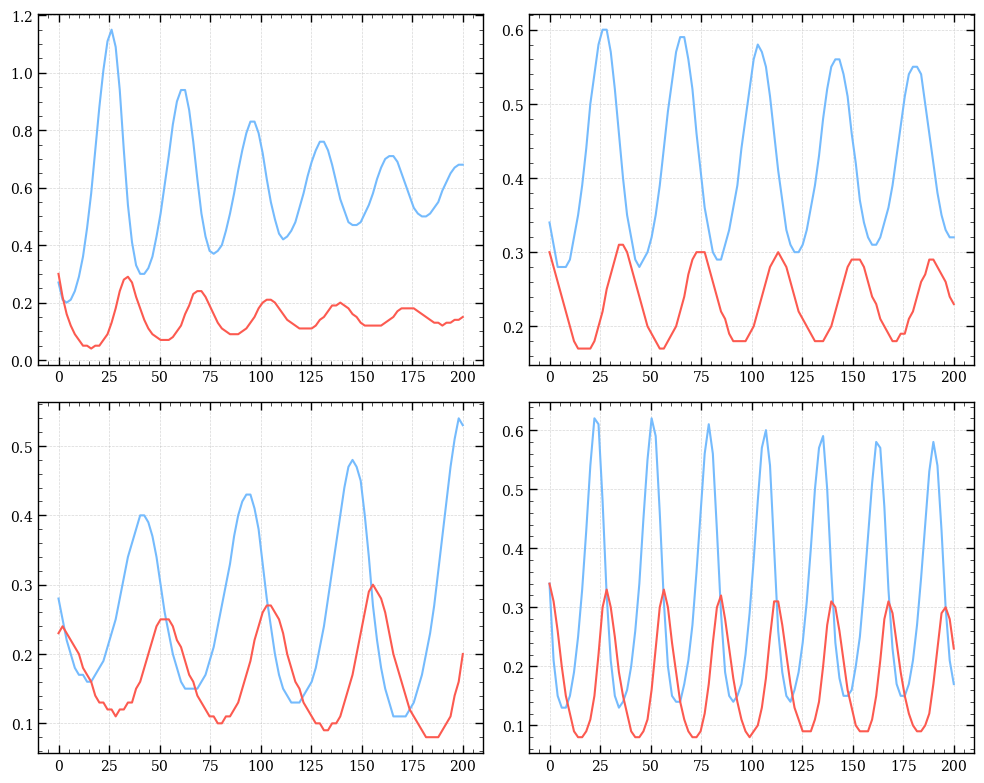

In [5]:
scaled_rounded_trajectories = np.round(trajectories / np.percentile(trajectories, 95), 2)

plt.figure(figsize=(10, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    system_id = i * 100  # Sample different systems
    plt.plot(time_points, scaled_rounded_trajectories[system_id, :, 0], label='Prey')
    plt.plot(time_points, scaled_rounded_trajectories[system_id, :, 1], label='Predator')
    # plt.xlabel('Time')
    # plt.ylabel('Population')
    # plt.title(f'System {system_id}')
    # plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.savefig('../results/figures/traj_0.pdf')

### 2.3 My Choice


Scaling to a smaller range can produce wiggly and rough results (see the fig above). In such cases, we may prefer to increase the number of decimal places when rounding. However, this means that each value requires **at least 5 tokens** (x.xxx), which is computationally expensive.

We propose scaling the 99th percentile to 10, which effectively preserves information, except for minor errors due to floating-point calculations. Additionally, rounding to two decimal places ensures that, in approximately **99% of cases**, each value requires **only 4 tokens** (x.xx).

(In practice, we apply the 99th percentile scaling based solely on the training data.)

The processed data appears significantly smoother than the previous one:



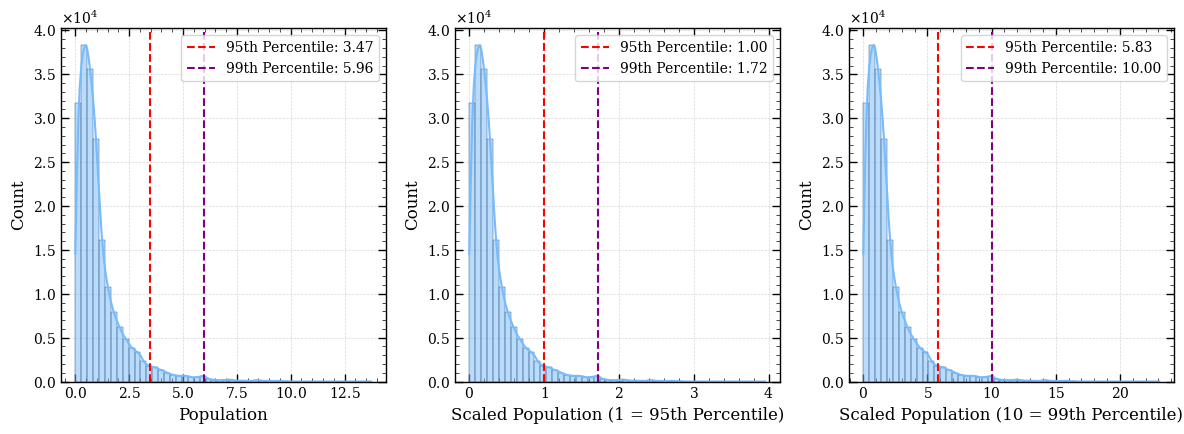

In [6]:
# Visualise the effect of scaling based on the 99th percentile
plt.figure(figsize=(12, 4.5))
plt.subplot(1, 3, 1)
sns.histplot(traj_values, edgecolor='xkcd:denim', kde=True, bins=50)
plt.axvline(traj_percentiles['95th'], color='r', linestyle='--', 
            label=f'95th Percentile: {traj_percentiles["95th"]:.2f}')
plt.axvline(traj_percentiles['99th'], color='purple', linestyle='--', 
            label=f'99th Percentile: {traj_percentiles["99th"]:.2f}')
# plt.title('Original Trajectory Distribution')
plt.xlabel('Population')
plt.legend()

scaled_traj_values = traj_values / np.percentile(traj_values, 95)
plt.subplot(1, 3, 2)
sns.histplot(scaled_traj_values, edgecolor='xkcd:denim', kde=True, bins=50)
plt.axvline(np.percentile(scaled_traj_values, 95), color='r', linestyle='--', 
            label=f'95th Percentile: {np.percentile(scaled_traj_values, 95):.2f}')
plt.axvline(np.percentile(scaled_traj_values, 99), color='purple', linestyle='--', 
            label=f'99th Percentile: {np.percentile(scaled_traj_values, 99):.2f}')
# plt.title('Scaled Trajectory Distribution')
plt.xlabel('Scaled Population (1 = 95th Percentile)')
plt.legend()

scaled_traj_values = traj_values / np.percentile(traj_values, 99) * 10
plt.subplot(1, 3, 3)
sns.histplot(scaled_traj_values, edgecolor='xkcd:denim', kde=True, bins=50)
plt.axvline(np.percentile(scaled_traj_values, 95), color='r', linestyle='--', 
            label=f'95th Percentile: {np.percentile(scaled_traj_values, 95):.2f}')
plt.axvline(np.percentile(scaled_traj_values, 99), color='purple', linestyle='--', 
            label=f'99th Percentile: {np.percentile(scaled_traj_values, 99):.2f}')
# plt.title('Scaled Trajectory Distribution')
plt.xlabel('Scaled Population (10 = 99th Percentile)')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/dists.pdf')

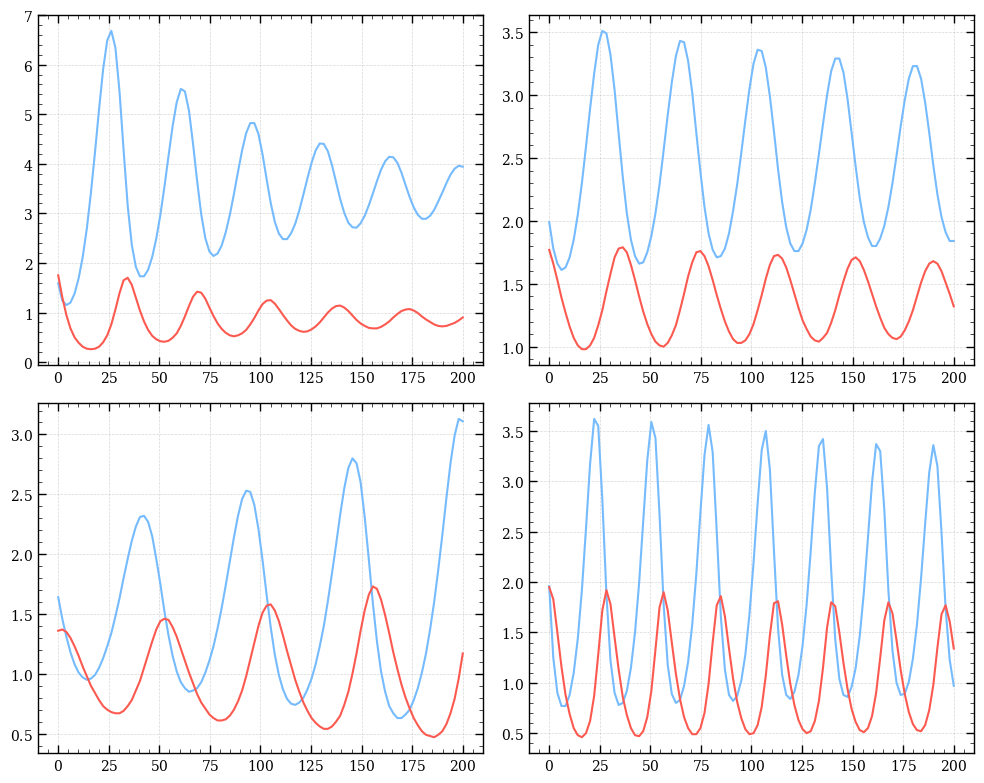

In [7]:
scaled_rounded_trajectories = np.round(trajectories / np.percentile(trajectories, 99) * 10, 2)

plt.figure(figsize=(10, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    system_id = i * 100  # Sample different systems
    plt.plot(time_points, scaled_rounded_trajectories[system_id, :, 0], label='Prey')
    plt.plot(time_points, scaled_rounded_trajectories[system_id, :, 1], label='Predator')
    # plt.xlabel('Time')
    # plt.ylabel('Population')
    # plt.title(f'System {system_id}')
    # plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.savefig('../results/figures/traj_1.pdf')